In [10]:

import time
import random
import matplotlib.pyplot as plt

In [9]:
# Node
class Node:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None
        self.height = 1

In [6]:
# AVL TREE
def height(root):
    if root is None:
        return 0
    return root.height

In [7]:
def balance(root):
    if root is None:
        return 0
    return height(root.left) - height(root.right)


In [ ]:
# Right Rotation - LL
def right_rotate(root):
    x = root.left
    temp = x.right

    x.right = root
    root.left = temp

    root.height = 1 + max(height(root.left),
                           height(root.right))

    x.height = 1 + max(height(x.left),
                       height(x.right))

    return x

In [11]:
# Left Rotation - RR
def left_rotate(root):
    x = root.right
    temp = x.left

    x.left = root
    root.right = temp

    root.height = 1 + max(height(root.left),
                           height(root.right))

    x.height = 1 + max(height(x.left),
                       height(x.right))

    return x

In [16]:
# AVL Insertion
def insert(root, key):

    # Normal BST insertion
    if root is None:
        return Node(key)

    if key < root.key:
        root.left = insert(root.left, key)

    elif key > root.key:
        root.right = insert(root.right, key)

    else:
        return root

         # Update height
    root.height = 1 + max(height(root.left),
                          height(root.right))

      # Find balance factor
    bf = balance(root)

    # LL Case
    if bf > 1 and key < root.left.key:
        return right_rotate(root)

    # RR Case
    if bf < -1 and key > root.right.key:
        return left_rotate(root)

    # LR Case
    if bf > 1 and key > root.left.key:
        root.left = left_rotate(root.left)
        return right_rotate(root)

    # RL Case
    if bf < -1 and key < root.right.key:
        root.right = right_rotate(root.right)
        return left_rotate(root)

    return root

In [17]:

# Find smallest node
def min_value(root):
    while root.left:
        root = root.left
    return root

In [22]:
# AVL Deletion
def delete(root, key):

    if root is None:
        return None

    # Search for the node
    if key < root.key:
        root.left = delete(root.left, key)

    elif key > root.key:
        root.right = delete(root.right, key)

    else:

        # No child
        if root.left is None and root.right is None:
            return None

             # Only right child
        if root.left is None:
            return root.right

        # Only left child
        if root.right is None:
            return root.left

        # Two children
        temp = min_value(root.right)
        root.key = temp.key
        root.right = delete(root.right, temp.key)

    # Update height
    root.height = 1 + max(height(root.left),
                          height(root.right))

    bf = balance(root)

    # LL
    if bf > 1 and balance(root.left) >= 0:
        return right_rotate(root)

    # LR
    if bf > 1 and balance(root.left) < 0:
        root.left = left_rotate(root.left)
        return right_rotate(root)

    # RR
    if bf < -1 and balance(root.right) <= 0:
        return left_rotate(root)

    # RL
    if bf < -1 and balance(root.right) > 0:
        root.right = right_rotate(root.right)
        return left_rotate(root)
        return root
    

In [23]:
 # Inorder traversal
def inorder(root, result):

    if root:
        inorder(root.left, result)
        result.append(root.key)
        inorder(root.right, result)

In [24]:
# Display height and balance factor
def display(root):

    if root:
        display(root.left)

        print("Node:", root.key,
              "Height:", root.height,
              "Balance Factor:", balance(root))

        display(root.right)

In [25]:
# BST
def bst_insert(root, key):

    if root is None:
        return Node(key)

    if key < root.key:
        root.left = bst_insert(root.left, key)

    elif key > root.key:
        root.right = bst_insert(root.right, key)

    return root

In [26]:
def bst_search(root, key):

    if root is None:
        return False

    if root.key == key:
        return True

    if key < root.key:
        return bst_search(root.left, key)

    return bst_search(root.right, key)

In [27]:
def avl_search(root, key):

    if root is None:
        return False

    if root.key == key:
        return True

    if key < root.key:
        return avl_search(root.left, key)

    return avl_search(root.right, key)


In [28]:
# BST Height
def bst_height(root):

    if root is None:
        return 0

    return 1 + max(bst_height(root.left),
                   bst_height(root.right))


In [29]:
# READ INPUT FILE

with open("input.txt", "r") as file:
    numbers = list(map(int, file.read().split()))


print("Input:")
print(numbers)

Input:
[50, 30, 70, 20, 40, 60, 80, 10, 25, 35, 45, 55, 65, 75, 90]


In [30]:
# BUILD AVL TREE

root = None
for number in numbers:
    root = insert(root, number)
print("\nAVL Tree Height:", height(root))
print("\nHeight and Balance Factor:")
display(root)



AVL Tree Height: 4

Height and Balance Factor:
Node: 10 Height: 1 Balance Factor: 0
Node: 20 Height: 2 Balance Factor: 0
Node: 25 Height: 1 Balance Factor: 0
Node: 30 Height: 3 Balance Factor: 0
Node: 35 Height: 1 Balance Factor: 0
Node: 40 Height: 2 Balance Factor: 0
Node: 45 Height: 1 Balance Factor: 0
Node: 50 Height: 4 Balance Factor: 0
Node: 55 Height: 1 Balance Factor: 0
Node: 60 Height: 2 Balance Factor: 0
Node: 65 Height: 1 Balance Factor: 0
Node: 70 Height: 3 Balance Factor: 0
Node: 75 Height: 1 Balance Factor: 0
Node: 80 Height: 2 Balance Factor: 0
Node: 90 Height: 1 Balance Factor: 0


In [31]:
# INORDER
result = []
inorder(root, result)
print("\nInorder Traversal:")
print(result)


Inorder Traversal:
[10, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90]


In [32]:
# WRITE OUTPUT FILE
with open("output.txt", "w") as file:
    file.write(" ".join(map(str, result)))

print("\nInorder traversal saved in output.txt")


Inorder traversal saved in output.txt


In [33]:
# DELETE A NODE
if numbers:

    key = numbers[len(numbers) // 2]

    print("\nDeleting:", key)

    root = delete(root, key)

    result = []
    inorder(root, result)

    print("Inorder after deletion:")
    print(result)

    print("Height after deletion:", height(root))



Deleting: 10
Inorder after deletion:
[]
Height after deletion: 0


In [40]:
# AVL VS BST SEARCH TIME
sizes = [100, 500, 1000, 5000, 10000]

avl_heights = []
bst_heights = []

avl_times = []
bst_times = []

for n in sizes:

    # Generate random unique numbers
    values = random.sample(range(1, n * 10), n)

     # AVL
    avl_root = None
    for x in values:
        avl_root = insert(avl_root, x)

        # BST
    bst_root = None
    for x in values:
        bst_root = bst_insert(bst_root, x)


        #search keys
    search_keys = random.sample(values, min(1000, n))

    # Repeat to make timing measurable
    search_keys = search_keys * 10

    # AVL search time
    start = time.perf_counter()

    for x in search_keys:
        avl_search(avl_root, x)

    avl_time = time.perf_counter() - start

    # BST search time
    start = time.perf_counter()

    for x in search_keys:
        bst_search(bst_root, x)

    bst_time = time.perf_counter() - start


    # Save results
    avl_heights.append(height(avl_root))
    bst_heights.append(bst_height(bst_root))

    avl_times.append(avl_time)
    bst_times.append(bst_time)

In [42]:
# DISPLAY RESULTS
print("AVL vs BST Results")

print("Nodes\tAVL Height\tBST Height\tAVL Search\tBST Search")

for i in range(len(sizes)):

    print(
        sizes[i], "\t",
        avl_heights[i], "\t\t",
        bst_heights[i], "\t\t",
        round(avl_times[i], 6), "\t",
        round(bst_times[i], 6)
    )

AVL vs BST Results
Nodes	AVL Height	BST Height	AVL Search	BST Search
100 	 8 		 17 		 0.000877 	 0.000826
500 	 10 		 20 		 0.004367 	 0.008943
1000 	 12 		 21 		 0.011139 	 0.017455
5000 	 15 		 29 		 0.017239 	 0.020365
10000 	 16 		 36 		 0.017484 	 0.025419


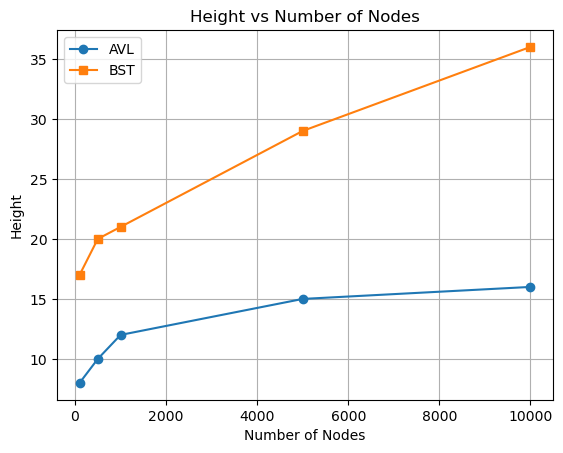

In [43]:

# GRAPH 1
# HEIGHT VS NUMBER OF NODES

plt.figure()
plt.plot(
    sizes,
    avl_heights,
    marker="o",
    label="AVL"
)

plt.plot(
    sizes,
    bst_heights,
    marker="s",
    label="BST"
)

plt.xlabel("Number of Nodes")
plt.ylabel("Height")
plt.title("Height vs Number of Nodes")

plt.legend()
plt.grid()

plt.savefig("height_comparison.png")

plt.show()


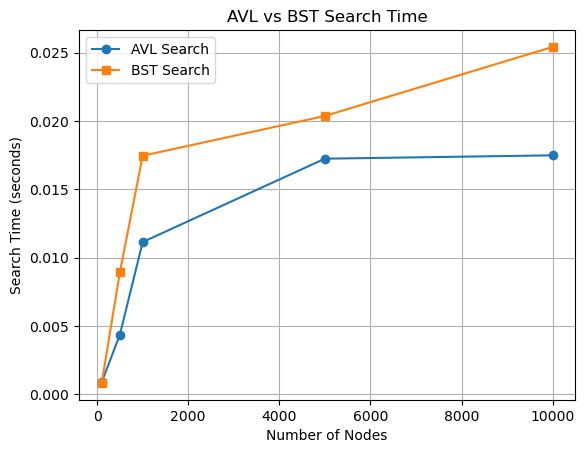

In [44]:
# GRAPH 2
# SEARCH TIME
plt.figure()

plt.plot(
    sizes,
    avl_times,
    marker="o",
    label="AVL Search"
)

plt.plot(
    sizes,
    bst_times,
    marker="s",
    label="BST Search"
)

plt.xlabel("Number of Nodes")
plt.ylabel("Search Time (seconds)")
plt.title("AVL vs BST Search Time")

plt.legend()
plt.grid()

plt.savefig("search_time_comparison.png")

plt.show()